# Student Exam Performance

#### Import dependencies

In [28]:
#!pip install pandas scikit-learn matplotlib seaborn gradio
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error , r2_score , mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

#### Load the dataset using pandas	

In [29]:
data = pd.read_csv(r"Student_Exam_Performance.csv")

#### Print the first few rows to inspect the data	

In [30]:
data.head()

,Gender,Parental Education Level,Lunch Type,Test Preparation Course,Study Time,Absences,Math Score,Reading Score,Writing Score
0,Male,Bachelor,Standard,Completed,7.0,0,91.911467,83.495543,89.545740
1,Female,Associate,Free/Reduced,NaN,3.0,4,53.368888,46.932742,60.787848
2,Male,Associate,Standard,Completed,6.0,5,78.681731,78.613855,82.795338
3,Female,Bachelor,Free/Reduced,NaN,0.0,1,40.716589,38.756995,45.371510
4,Male,Bachelor,Free/Reduced,Completed,2.0,11,52.541330,53.477615,66.229557


#### Check for any missing values

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    1000 non-null   object 
 1   Parental Education Level  966 non-null    object 
 2   Lunch Type                963 non-null    object 
 3   Test Preparation Course   477 non-null    object 
 4   Study Time                955 non-null    float64
 5   Absences                  1000 non-null   int64  
 6   Math Score                956 non-null    float64
 7   Reading Score             1000 non-null   float64
 8   Writing Score             1000 non-null   float64
dtypes: float64(4), int64(1), object(4)
memory usage: 70.4+ KB


In [32]:
data.isna().sum()

Gender                        0
Parental Education Level     34
Lunch Type                   37
Test Preparation Course     523
Study Time                   45
Absences                      0
Math Score                   44
Reading Score                 0
Writing Score                 0
dtype: int64

#### Handling the missing values

In [33]:
data['Test Preparation Course'] = data['Test Preparation Course'].fillna('Not Completed')

In [34]:
data.dropna(inplace=True)

In [35]:
data.isna().sum()

Gender                      0
Parental Education Level    0
Lunch Type                  0
Test Preparation Course     0
Study Time                  0
Absences                    0
Math Score                  0
Reading Score               0
Writing Score               0
dtype: int64

#### make exam score 

In [36]:
data["Exam Score"] = data['Math Score'] + data['Writing Score'] + data['Reading Score']
data.drop(['Math Score', 'Writing Score', 'Reading Score'], axis = 1 , inplace = True)

#### Encode categorical columns

In [37]:
categorical_cols = ['Gender', 'Parental Education Level', 'Lunch Type', 'Test Preparation Course']

le = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])
    le[col] = encoder

#### Normalize or scale numeric columns

In [38]:
numeric_cols = ['Study Time', 'Absences']
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

#### Generate summary statistics of the dataset	

In [39]:
data.describe()

,Gender,Parental Education Level,Lunch Type,Test Preparation Course,Study Time,Absences,Exam Score
count,847.000000,847.000000,847.000000,847.000000,8.470000e+02,8.470000e+02,847.000000
mean,0.507674,2.082645,0.510035,0.527745,2.516680e-17,1.011915e-16,207.428282
std,0.500236,1.364102,0.500195,0.499525,1.000591e+00,1.000591e+00,49.964064
min,0.000000,0.000000,0.000000,0.000000,-1.567775e+00,-1.614551e+00,91.740165
25%,0.000000,1.000000,0.000000,0.000000,-9.345343e-01,-7.972401e-01,165.156281
50%,1.000000,2.000000,1.000000,1.000000,1.532636e-02,2.007092e-02,207.133539
75%,1.000000,3.000000,1.000000,1.000000,9.651870e-01,8.373819e-01,248.146892
max,1.000000,4.000000,1.000000,1.000000,1.598427e+00,1.654693e+00,300.000000


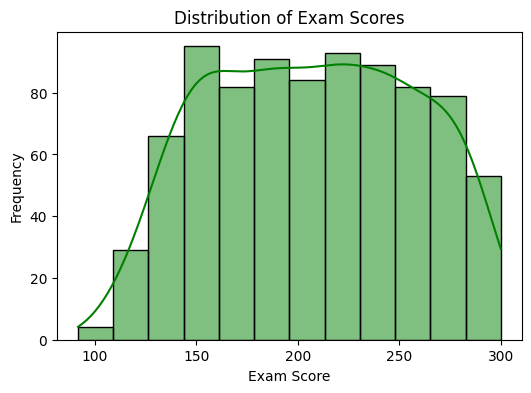

In [40]:
plt.figure(figsize=(6, 4))
sns.histplot(data["Exam Score"], color="green", kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

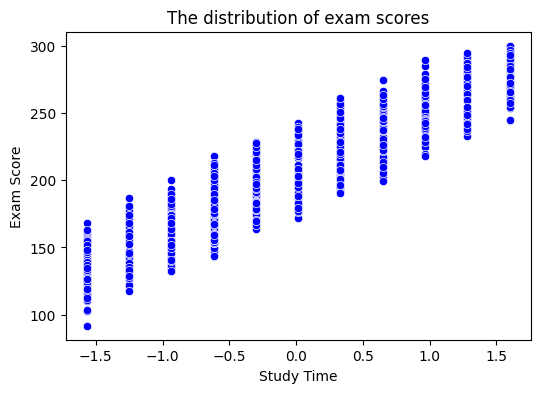

In [41]:
plt.figure(figsize=(6,4))
sns.scatterplot(data = data , x = "Study Time" , y = "Exam Score" , color = "blue")
plt.title("The distribution of exam scores")
plt.xlabel("Study Time")
plt.ylabel("Exam Score")
plt.show()

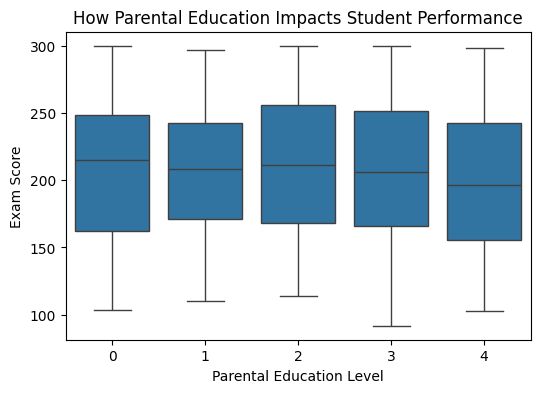

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(data=data , x = "Parental Education Level" , y = "Exam Score")
plt.title("How Parental Education Impacts Student Performance")
plt.xlabel("Parental Education Level")
plt.ylabel("Exam Score")
plt.show()

#### Separate features (X) and labels (y).

In [43]:
x = data.drop("Exam Score",axis = 1)
y = data["Exam Score"]

#### Use train_test_split from sklearn to split the data into 80% training and 20% testing	

In [44]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 , random_state=42)

#### Linear Regression

In [45]:
lr = LinearRegression()
lr.fit(x_train , y_train)
lr_y_pred = lr.predict(x_test)
print("MSE = ",mean_squared_error(y_test , lr_y_pred))
print("MAE = ",mean_absolute_error(y_test , lr_y_pred))
print("R2_score = ",r2_score(y_test , lr_y_pred))

MSE =  101.77602752078806
MAE =  8.071064631718565
R2_score =  0.9605439874841337


#### Random Forest Regressor

In [46]:
rf = RandomForestRegressor()
rf.fit(x_train , y_train)
rf_y_pred = rf.predict(x_test)
print("MSE = ",mean_squared_error(y_test , rf_y_pred))
print("MAE = ",mean_absolute_error(y_test , rf_y_pred))
print("R2_score = ",r2_score(y_test , rf_y_pred))

MSE =  129.8381685913999
MAE =  9.160951040267602
R2_score =  0.9496649994132158


#### Decision Tree Regressor

In [47]:
dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)
dt_y_pred = dt.predict(x_test)
print("MSE = ",mean_squared_error(y_test , dt_y_pred))
print("MAE = ",mean_absolute_error(y_test , dt_y_pred))
print("r2_score = ",r2_score(y_test , dt_y_pred))

MSE =  185.65038424786087
MAE =  10.970267505397317
r2_score =  0.9280280036184078


#### Plot predicted vs. actual values using a scatter plot.	

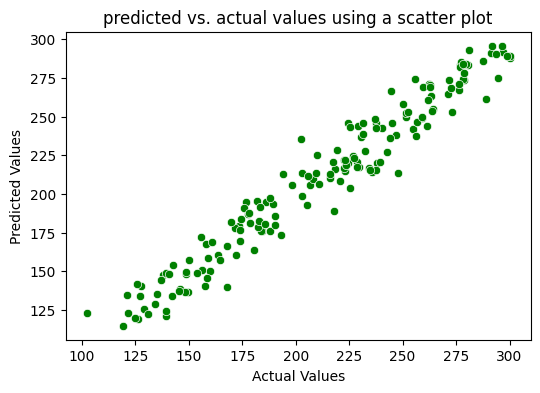

In [48]:
plt.figure(figsize=(6,4))
sns.scatterplot(x = y_test , y = rf_y_pred , color = 'green')
plt.title("predicted vs. actual values using a scatter plot")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

In [49]:
grid_params = {
    "max_depth": [x for x in range(25, 70)],
    "max_leaf_nodes": [x for x in range(20, 30)]  
}
grid_model = GridSearchCV(DecisionTreeRegressor(), grid_params, cv=5)
grid_model.fit(x_train, y_train)
print(grid_model.best_params_)
print(grid_model.best_score_)

{'max_depth': 25, 'max_leaf_nodes': 22}
0.9601137323719723


In [50]:
def predict(Gender,Parental_Education_Level, Lunch_Type,test_prep, Study_Time, Absences):
    try:
        input_data = pd.DataFrame({
            "Gender": [Gender],
            "Parental Education Level": [Parental_Education_Level],
            "Lunch Type": [Lunch_Type],
            "Test Preparation Course": [test_prep],
            "Study Time": [Study_Time],
            "Absences": [Absences]
        })
        for col in le:
            input_data[col] = le[col].transform(input_data[col])
        input_data[numeric_cols] = scaler.transform(input_data[numeric_cols])
        prediction = rf.predict(input_data)[0]
        return f"Predicted Result: {prediction}"
    except Exception as e:
        return f"Error: {e}"

In [51]:
gr.Interface(
    fn = predict,
    inputs = [
        gr.Dropdown(label = "Gender " , choices  = ["Male" , "Female"]),
        gr.Dropdown(label = "Parental Education Level" , choices = ["Bachelor" , "College" , "High School","Master"]),
        gr.Dropdown(label = "Lunch Type" , choices = ["Standard" , "Free/Reduced"]),
        gr.Dropdown(label = "Test Preparation Course", choices = ["Completed" , "Not Completed"]),
        gr.Number(label = "Study Time"),
        gr.Number(label = "Absences")
    ],
    outputs = "text",
    title = "Student performance Exam"
).launch()

* Running on local URL:  http://127.0.0.1:7870
* To create a public link, set `share=True` in `launch()`.
